In [ ]:
%load_ext autoreload
%autoreload 2

In [130]:
import os
import numpy as np
import pylab as plt
import networkx as nx
from sklearn.neighbors import kneighbors_graph
from sklearn.metrics import pairwise_distances
from modules import MDSTorusProjector, apsp_distance_matrix, plot_embedding_with_torus_edges

In [ ]:
data_path = "/gpfs01/berens/user/sdamrich/data/graph_torus/3figures"
pca = np.load(os.path.join(data_path, "yoda_bulldog_pca50.npy"))
phases = np.load(os.path.join(data_path, "phases.npy"))
print(pca.shape, phases.shape)

In [90]:
# subsampled data

In [91]:
## knn graph

In [113]:
k = 15
A = kneighbors_graph(pca[:1000, :4], n_neighbors=k, mode='connectivity', include_self=False)
A = A.maximum(A.T)  # symmetrize: union of directed edges, keeps values in {0, 1}
G = nx.from_scipy_sparse_array(A)
print(f"{G.number_of_nodes()} nodes, {G.number_of_edges()} edges, connected: {nx.is_connected(G)}")

1000 nodes, 8539 edges, connected: True


In [114]:
D, nodes = apsp_distance_matrix(G)
print(D.shape)

(1000, 1000)


(array([ 18078.,  81176., 132476., 137018., 125536., 121746., 121108.,
        122468., 113316.,  27078.]),
 array([ 0.,  2.,  4.,  6.,  8., 10., 12., 14., 16., 18., 20.]),
 <BarContainer object of 10 artists>)

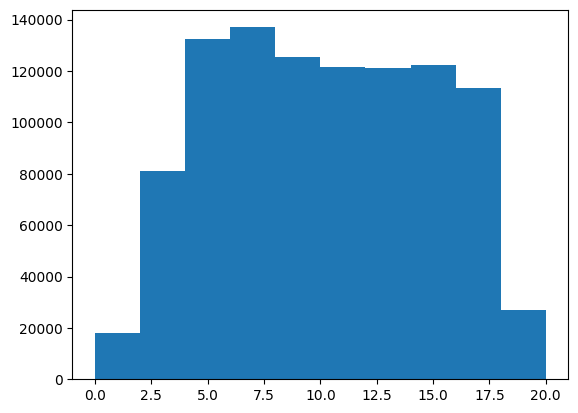

In [115]:
plt.hist(D.flatten())

In [116]:
proj = MDSTorusProjector()
X = proj.fit_transform(D/D.max(), learn_mode='rectangular', r0_init=1.5, r1_init=1)

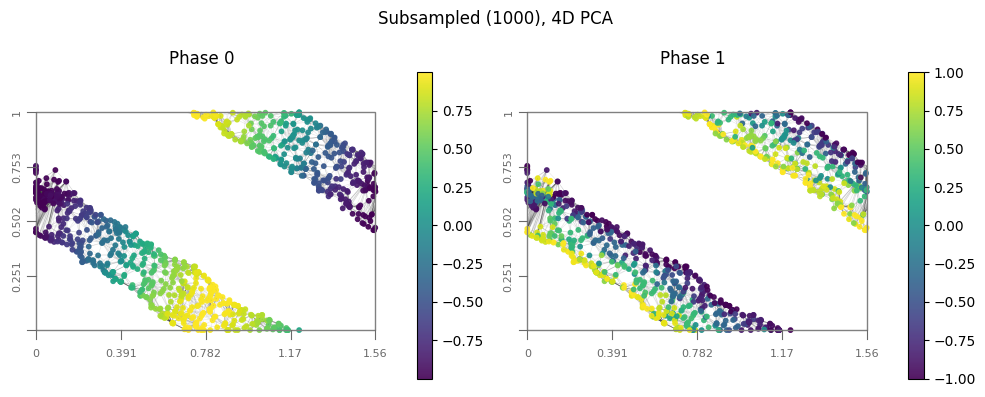

In [117]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, ax in enumerate(axes):
    plot_embedding_with_torus_edges(X=X, G=G, torus=proj, colors=phases[:1000, i], ax=ax)
    plt.colorbar(ax.collections[-1], ax=ax)
    ax.set_title(f"Phase {i}")
plt.suptitle("Subsampled (1000), 4D PCA")
plt.tight_layout()
plt.show()

In [106]:
## eucl dists

In [107]:
D = pairwise_distances(pca[:1000, :4])

(array([ 21428.,  50926.,  75934., 101792., 144674., 137384., 138512.,
        162944., 146372.,  20034.]),
 array([    0.        ,  1008.03921261,  2016.07842523,  3024.11763784,
         4032.15685045,  5040.19606307,  6048.23527568,  7056.27448829,
         8064.31370091,  9072.35291352, 10080.39212613]),
 <BarContainer object of 10 artists>)

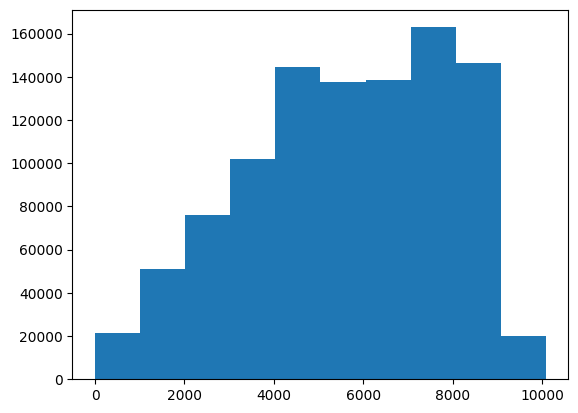

In [108]:
plt.hist(D.flatten())

In [109]:
proj = MDSTorusProjector()
X = proj.fit_transform(D/D.max(), learn_mode='rectangular', r1_init=1, r0_init=2)

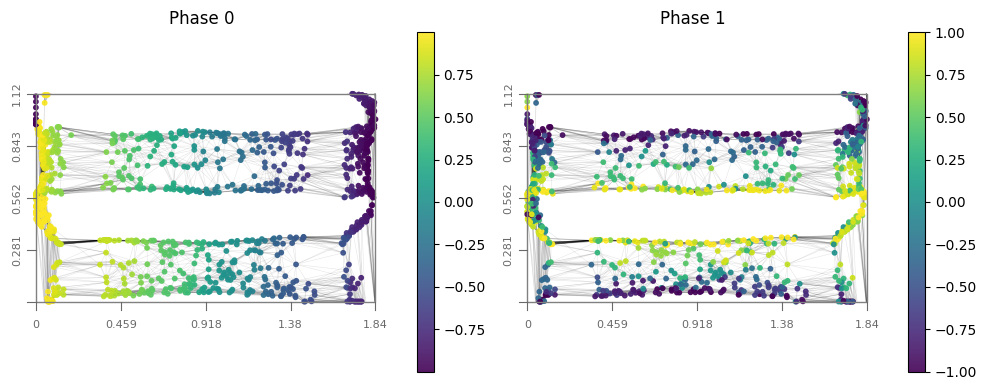

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, ax in enumerate(axes):
    plot_embedding_with_torus_edges(X=X, G=G, torus=proj, colors=phases[:1000, i], ax=ax)
    plt.colorbar(ax.collections[-1], ax=ax)
    ax.set_title(f"Phase {i}")
plt.tight_layout()
plt.show()

In [111]:
proj = MDSTorusProjector()
X = proj.fit_transform(D/D.max(), learn_mode='rectangular', r1_init=1, r0_init=1)

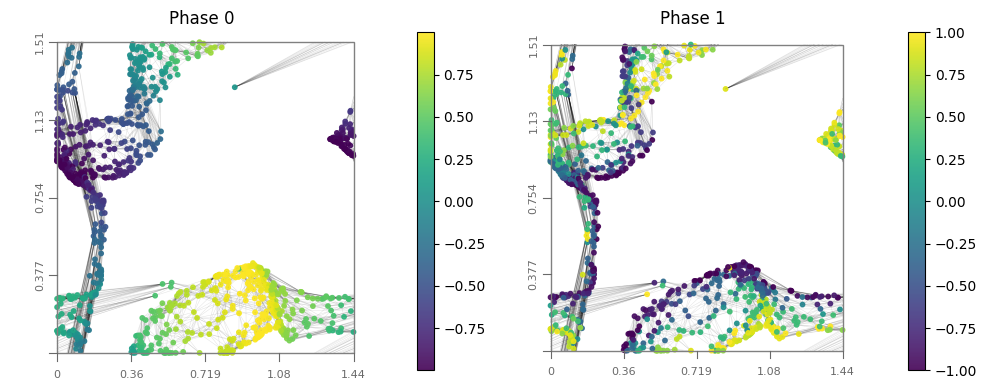

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, ax in enumerate(axes):
    plot_embedding_with_torus_edges(X=X, G=G, torus=proj, colors=phases[:1000, i], ax=ax)
    plt.colorbar(ax.collections[-1], ax=ax)
    ax.set_title(f"Phase {i}")
plt.tight_layout()
plt.show()

In [ ]:
# all points

## All points (8100), 4D PCA

In [118]:
k = 15
A = kneighbors_graph(pca[:, :4], n_neighbors=k, mode='connectivity', include_self=False)
A = A.maximum(A.T)
G_full_4d = nx.from_scipy_sparse_array(A)
print(f"{G_full_4d.number_of_nodes()} nodes, {G_full_4d.number_of_edges()} edges, connected: {nx.is_connected(G_full_4d)}")

8100 nodes, 70144 edges, connected: True


In [126]:
# apsp takes too long to compute, only do eucl dist
D_full_4d_eucl = pairwise_distances(pca[:, :4])

In [127]:
proj_full_4d_eucl = MDSTorusProjector()
X_full_4d_eucl = proj_full_4d_eucl.fit_transform(D_full_4d_eucl/D_full_4d_eucl.max(), learn_mode='rectangular', r0_init=1.5, r1_init=1)

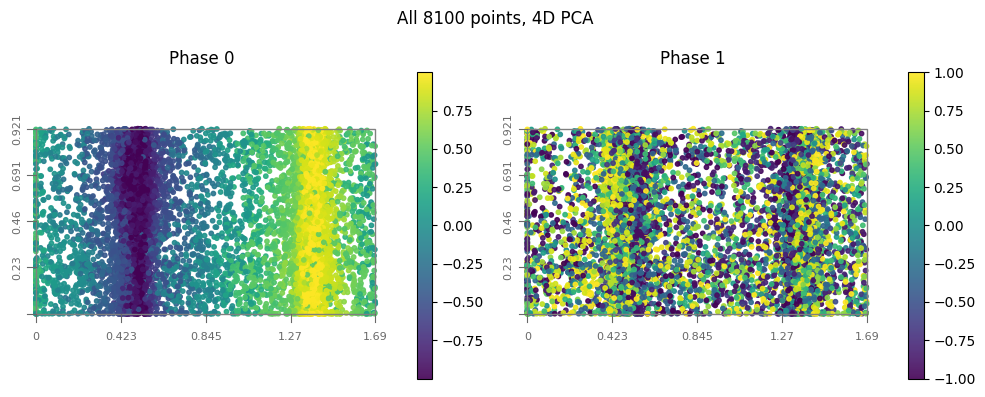

In [132]:

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, ax in enumerate(axes):
    plot_embedding_with_torus_edges(X=X_full_4d_eucl, G=None, torus=proj_full_4d_eucl, colors=phases[:, i], ax=ax)
    plt.colorbar(ax.collections[-1], ax=ax)
    ax.set_title(f"Phase {i}")
plt.suptitle("All 8100 points, 4D PCA")
plt.tight_layout()
plt.show()

## Subsampled (1000 points), all 50D PCA

In [135]:
# only optionally for plotting
k = 15
A = kneighbors_graph(pca, n_neighbors=k, mode='connectivity', include_self=False)
A = A.maximum(A.T)
G_50d = nx.from_scipy_sparse_array(A)
print(f"{G_50d.number_of_nodes()} nodes, {G_50d.number_of_edges()} edges, connected: {nx.is_connected(G_50d)}")

8100 nodes, 69505 edges, connected: True


In [137]:
D_50d = pairwise_distances(pca)

In [138]:
proj_50d = MDSTorusProjector()
X_50d = proj_50d.fit_transform(D_50d/D_50d.max(), learn_mode='rectangular', r0_init=1.5, r1_init=1)

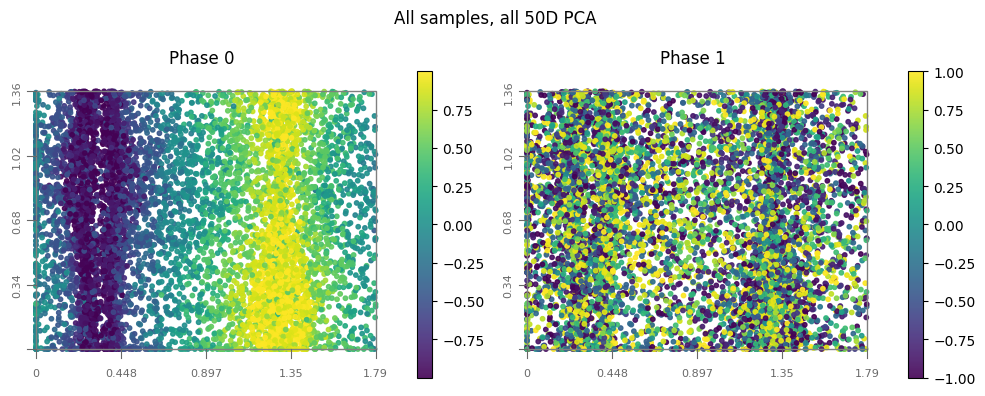

In [139]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for i, ax in enumerate(axes):
    plot_embedding_with_torus_edges(X=X_50d, G=None, torus=proj_50d, colors=phases[:, i], ax=ax)
    plt.colorbar(ax.collections[-1], ax=ax)
    ax.set_title(f"Phase {i}")
plt.suptitle("All samples, all 50D PCA")
plt.tight_layout()
plt.show()

## All points (8100), all 50D PCA